In [29]:
import pymupdf

# Path to the PDF file
pdf_path = 'data/anes_timeseries_2020_userguidecodebook_20220210.pdf'

# Open the PDF
doc = pymupdf.open(pdf_path)

# Extract text from all pages
full_text = ""
for page_num in range(len(doc)):
    page = doc[page_num]
    full_text += page.get_text()

# Close the document
doc.close()

# Save the text to a file
output_path = 'data/anes_timeseries_2020_userguidecodebook_20220210.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(full_text)

print(f"PDF converted successfully!")
print(f"Text saved to: {output_path}")
print(f"Total characters extracted: {len(full_text)}")
print(f"\nFirst 500 characters:\n{full_text[:500]}")

PDF converted successfully!
Text saved to: data/anes_timeseries_2020_userguidecodebook_20220210.txt
Total characters extracted: 890526

First 500 characters:
ANES 2020 Time Series Study
Full Release
User Guide and Codebook 
February 10, 2022
iii
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 


In [30]:
import re

# Read the text file
with open('data/anes_timeseries_2020_userguidecodebook_20220210.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# Split by lines
lines = text.split('\n')

# Extract variables, questions, and value labels
questions = []
skipped_questions = []
i = 0
while i < len(lines):
    line = lines[i].strip()
    
    # Look for variable codes (V followed by digits)
    if re.match(r'^V\d+[a-z]?$', line):
        var_code = line
        
        # Look ahead for "Question" label and extract the question text
        j = i + 1
        question_text = []
        found_question = False
        
        while j < len(lines):
            next_line = lines[j].strip()
            
            # Stop if we hit another variable or a section header
            if re.match(r'^V\d+[a-z]?$', next_line) or \
               next_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction', 
                            'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference']:
                break
            
            # Stop before "Value Labels"
            if next_line == 'Value Labels':
                break
            
            # Look for "Question" label
            if next_line.lower() == 'question':
                found_question = True
                j += 1
                continue
            
            # Collect question text after "Question" label
            if found_question and next_line:
                question_text.append(next_line)
            
            j += 1
        
        # Now look for "Value Labels" section
        value_labels = []
        if found_question and question_text:
            k = j
            while k < len(lines):
                next_line = lines[k].strip()
                
                # Found Value Labels section
                if next_line == 'Value Labels':
                    k += 1
                    # Collect all label lines until we hit another metadata section or variable
                    while k < len(lines):
                        label_line = lines[k].strip()
                        
                        # Stop at next metadata section or variable
                        if re.match(r'^V\d+[a-z]?$', label_line) or \
                           label_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction',
                                        'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference', 'Question']:
                            break
                        
                        if label_line:  # Only add non-empty lines
                            value_labels.append(label_line)
                        k += 1
                    break
                
                # Stop if we hit another section without finding Value Labels
                if re.match(r'^V\d+[a-z]?$', next_line) or \
                   next_line in ['Universe', 'Survey Question(s)', 'Interviewer Instruction',
                                'Variable Note', 'Randomization', 'Display Specification', 'Mode Difference']:
                    break
                
                k += 1
        
        # If we found a question, check if it should be included
        if found_question and question_text:
            # Join the question text and clean it up
            full_question = ' '.join(question_text).strip()
            
            # Check if value labels contain "open-end" or "restricted"
            has_open_end = any('open-end' in label.lower() for label in value_labels)
            has_restricted = any('restricted' in label.lower() for label in value_labels)
            
            if has_open_end or has_restricted:
                skipped_questions.append({
                    'variable_code': var_code,
                    'reason': 'open-end' if has_open_end else 'restricted'
                })
            else:
                questions.append({
                    'variable_code': var_code,
                    'question': full_question,
                    'labels': value_labels
                })
    
    i += 1

# Save to file
output_file = 'data/extracted_questions.txt'
with open(output_file, 'w', encoding='utf-8') as f:
    for item in questions:
        f.write(f"{item['variable_code']}\n")
        f.write(f"{item['question']}\n")
        if item['labels']:
            f.write("Value Labels\n")
            for label in item['labels']:
                f.write(f"{label}\n")
        f.write("\n")

print(f"Extracted {len(questions)} questions from the codebook")
print(f"Skipped {len(skipped_questions)} questions (open-end or restricted)")
print(f"Saved to: {output_file}")
print(f"\nFirst 3 examples:")
for i, item in enumerate(questions[:3]):
    print(f"\n{item['variable_code']}")
    print(f"{item['question'][:80]}...")
    if item['labels']:
        print("Value Labels:")
        for label in item['labels'][:3]:
            print(f"  {label}")
        if len(item['labels']) > 3:
            print(f"  ... and {len(item['labels']) - 3} more")

Extracted 1028 questions from the codebook
Skipped 193 questions (open-end or restricted)
Saved to: data/extracted_questions.txt

First 3 examples:

V201001
Would you like to complete this survey in English or Spanish? ¿Quisiera completa...
Value Labels:
  1. English / Ingles
  2. Spanish / Espanol

V201002a
We mailed you a booklet. It was enclosed with the letter inviting you to partici...
Value Labels:
  -1. Inapplicable
  1. R has booklet (paper or emailed)
  2. R does not have paper or email booklet

V201002b
For some of the questions, I’ll share my screen and show you a card with all the...
Value Labels:
  -4. Technical error
  -1. Inapplicable
  1. R sees booklet on screen or PDF
  ... and 1 more


In [31]:
import tiktoken

# Read the extracted questions file
with open('data/extracted_questions.txt', 'r', encoding='utf-8') as f:
    questions_text = f.read()

# Initialize the tokenizer
encoding = tiktoken.get_encoding("cl100k_base")  # This is the encoding for GPT-4 and GPT-3.5

# Count tokens
tokens = encoding.encode(questions_text)
token_count = len(tokens)

print(f"Token count for extracted questions: {token_count:,}")
print(f"File size: {len(questions_text):,} characters")
print(f"Average tokens per character: {token_count / len(questions_text):.3f}")
print(f"\nNumber of questions: {len(questions)}")
print(f"Average tokens per question: {token_count / len(questions):.1f}")

Token count for extracted questions: 84,765
File size: 315,077 characters
Average tokens per character: 0.269

Number of questions: 1028
Average tokens per question: 82.5


In [32]:
import pandas as pd
import numpy as np
from pathlib import Path

# Paths
raw_csv_path = Path("data/anes_timeseries_2020_csv_20220210.csv")
clean_csv_path = Path("data/policy_clean.csv")

# Load raw ANES data
print(f"Loading {raw_csv_path} ...")
df = pd.read_csv(raw_csv_path)

# Common missing codes to drop to NaN
missing_codes = {-9, -8, -7, -6, -5, -4, -3, -2, -1, 99}

def to_series(name):
    if name not in df.columns:
        return pd.Series([np.nan] * len(df))
    return df[name].replace(missing_codes, np.nan)

def to_series_any(names):
    for n in names:
        if n in df.columns:
            return df[n].replace(missing_codes, np.nan)
    return pd.Series([np.nan] * len(df))

def signed_with_strength(direction, strength, dir_map, str_map):
    d = to_series_any(direction if isinstance(direction, (list, tuple)) else [direction]).map(dir_map)
    s = to_series_any(strength if isinstance(strength, (list, tuple)) else [strength]).map(str_map)
    return d * s

# Direction-only ordinal helpers
policy = {}

# Ideology / partisanship
ideology_7 = to_series_any(["V201200"])
policy["ideology_7pt"] = ideology_7
policy["ideology_3pt_signed"] = ideology_7.map({1: 1, 2: 1, 3: 1, 4: 0, 5: -1, 6: -1, 7: -1})
policy["party_id_signed"] = to_series_any(["V201228"]).map({1: -1, 2: 1, 3: 0, 5: 0, 0: 0})

# Abortion
policy["abortion_4pt"] = to_series_any(["V201336"])
policy["abortion_importance_5"] = to_series_any(["V201337"])
policy["abortion_scotus_signed3"] = signed_with_strength(
    direction="V201340",  # 1 pleased, 2 upset, 3 neither
    strength="V201341",   # 1 extremely, 2 moderately, 3 a little
    dir_map={1: 1, 2: -1, 3: 0},
    str_map={1: 3, 2: 2, 3: 1},
)

# LGBTQ
policy["trans_bathroom_signed3"] = signed_with_strength(
    direction="V201409",  # 1 restrict, 2 allow
    strength="V201410",   # 1 very, 2 moderate, 3 a little
    dir_map={1: -1, 2: 1},
    str_map={1: 3, 2: 2, 3: 1},
)
policy["lgbt_job_protect_signed2"] = signed_with_strength(
    direction="V201412",  # 1 favor, 2 oppose
    strength="V201413",   # 1 strongly, 2 not strongly
    dir_map={1: 1, 2: -1},
    str_map={1: 2, 2: 1},
)
policy["gay_adoption_signed"] = to_series_any(["V201415"]).map({1: 1, 2: -1})
policy["gay_marriage_3pt"] = to_series_any(["V201416"]).map({1: 2, 2: 1, 3: -1})

# Immigration
policy["immigration_policy_4pt"] = to_series_any(["V201417"])
policy["birthright_signed"] = to_series_any(["V201418"]).map({1: -1, 2: 1, 3: 0})
# policy["dreamers_signed"] = to_series_any(["V201420", "V201420x"]).map({1: -1, 2: 1})
policy["border_wall_signed3"] = signed_with_strength(
    direction="V201424",  # 1 favor, 2 oppose, 3 neither
    strength="V201425",   # 1 great deal, 2 moderate, 3 a little
    dir_map={1: 1, 2: -1, 3: 0},
    str_map={1: 3, 2: 2, 3: 1},
)

# Environment / climate
policy["environment_regulation_7pt"] = to_series_any(["V201262"])
policy["climate_effect_5pt"] = to_series_any(["V202335"])
policy["climate_importance_5pt"] = to_series_any(["V202336", "V202336x"])

# Guns
policy["gun_rules_signed3"] = to_series_any(["V202337"]).map({1: 1, 2: -1, 3: 0})
policy["gun_rules_importance_5pt"] = to_series_any(["V202338"])
policy["background_checks_signed3"] = signed_with_strength(
    direction="V202339",  # 1 favor, 2 oppose, 3 neither
    strength="V202340",   # 1 great deal, 2 moderate, 3 a little
    dir_map={1: 1, 2: -1, 3: 0},
    str_map={1: 3, 2: 2, 3: 1},
)

# Health care
policy["obamacare_signed3"] = signed_with_strength(
    direction="V202326",  # 1 approve, 2 disapprove, 3 neither
    strength="V202327",   # 1 great deal, 2 moderate, 3 a little
    dir_map={1: 1, 2: -1, 3: 0},
    str_map={1: 3, 2: 2, 3: 1},
)
policy["vaccines_school_signed3"] = signed_with_strength(
    direction="V202329",  # 1 favor, 2 oppose, 3 neither
    strength="V202330",   # 1 great deal, 2 moderate, 3 a little
    dir_map={1: 1, 2: -1, 3: 0},
    str_map={1: 3, 2: 2, 3: 1},
)
policy["millionaire_tax_signed3"] = to_series_any(["V202325"]).map({1: 1, 2: -1, 3: 0})

# Economic / redistribution
policy["jobs_guarantee_7pt"] = to_series_any(["V201255"])  # 1 gov should see to jobs ... 7 personal
policy["aid_blacks_7pt"] = to_series_any(["V201258"])
policy["urban_unrest_7pt"] = to_series_any(["V201429"])
policy["minimum_wage_4pt"] = to_series_any(["V202348"]).map({1: 2, 2: 1, 3: -1, 4: -2})

# Criminal justice
policy["death_penalty_signed2"] = signed_with_strength(
    direction="V201343",  # 1 favor, 2 oppose
    strength="V201344",   # 1 strongly, 2 not strongly
    dir_map={1: 1, 2: -1},
    str_map={1: 2, 2: 1},
)

# Trade
policy["free_trade_signed3"] = to_series_any(["V202351"]).map({1: 1, 2: -1, 3: 0})

# Defense
policy["military_force_5pt"] = to_series_any(["V201350"])

# Assemble clean DataFrame
clean = pd.DataFrame(policy)

# Track which requested columns were missing from raw
missing_in_file = [name for name, series in policy.items() if series.isna().all()]
if missing_in_file:
    print("Warning: missing raw columns for:", missing_in_file)

non_null_counts = clean.notna().sum().sort_values(ascending=False)
print("Non-null counts per column:\n", non_null_counts)

clean.to_csv(clean_csv_path, index=False)
print(f"Saved cleaned policy dataset to {clean_csv_path}")

Loading data\anes_timeseries_2020_csv_20220210.csv ...


C:\Users\tiger\AppData\Local\Temp\ipykernel_303896\696357459.py:11: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_csv_path)


Non-null counts per column:
 abortion_importance_5         8237
party_id_signed               8231
birthright_signed             8231
military_force_5pt            8222
abortion_4pt                  8208
immigration_policy_4pt        8197
lgbt_job_protect_signed2      8161
gay_marriage_3pt              8161
gay_adoption_signed           8152
death_penalty_signed2         8113
trans_bathroom_signed3        7967
urban_unrest_7pt              7713
aid_blacks_7pt                7403
millionaire_tax_signed3       7384
gun_rules_importance_5pt      7378
gun_rules_signed3             7375
climate_importance_5pt        7364
minimum_wage_4pt              7332
jobs_guarantee_7pt            7322
environment_regulation_7pt    7124
ideology_3pt_signed           7056
ideology_7pt                  7056
background_checks_signed3     6850
border_wall_signed3           6768
vaccines_school_signed3       6239
obamacare_signed3             5946
abortion_scotus_signed3       5804
free_trade_signed3        

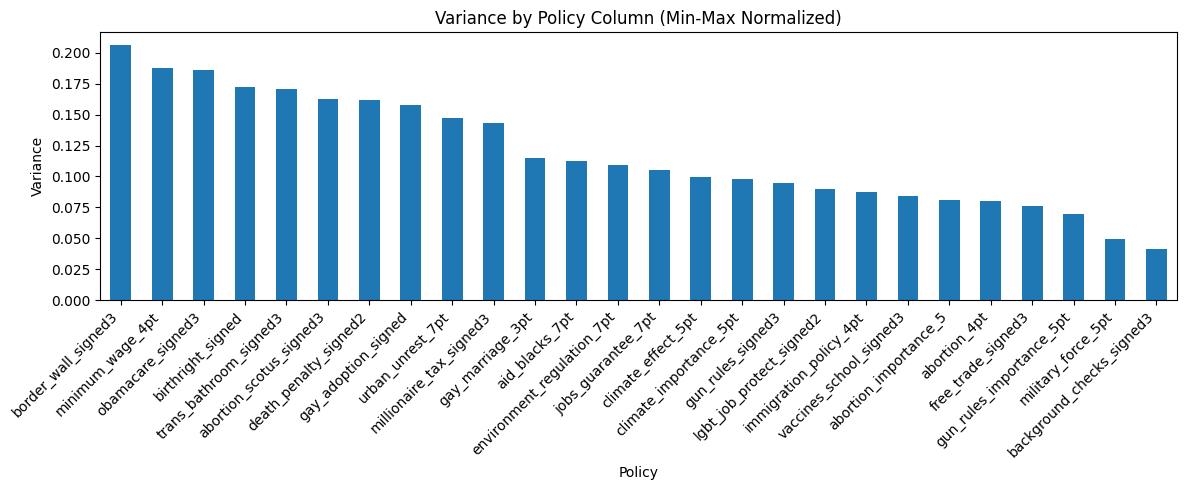

In [33]:
import matplotlib.pyplot as plt

# Load cleaned policy data
clean = pd.read_csv("data/policy_clean.csv")

# Define columns to exclude from normalization (ideology and partisanship)
exclude_cols = ['party_id_signed', 'ideology_7pt', 'ideology_3pt_signed']

# Get policy columns (exclude ideology/partisan columns)
policy_cols = [col for col in clean.columns if col not in exclude_cols]

# Min-max normalize policy columns only
col_min = clean[policy_cols].min(skipna=True)
col_max = clean[policy_cols].max(skipna=True)
col_range = col_max - col_min
safe_range = col_range.replace(0, np.nan)

clean_normalized = clean.copy()
clean_normalized[policy_cols] = (clean[policy_cols] - col_min) / safe_range

# Calculate variance for each policy
variance = {col: clean_normalized[col].var(skipna=True) for col in policy_cols}
variance_sorted = dict(sorted(variance.items(), key=lambda x: x[1], reverse=True))

# Plot 1: Variance
plt.figure(figsize=(12, 5))
pd.Series(variance_sorted).plot(kind='bar')
plt.title('Variance by Policy Column (Min-Max Normalized)')
plt.ylabel('Variance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

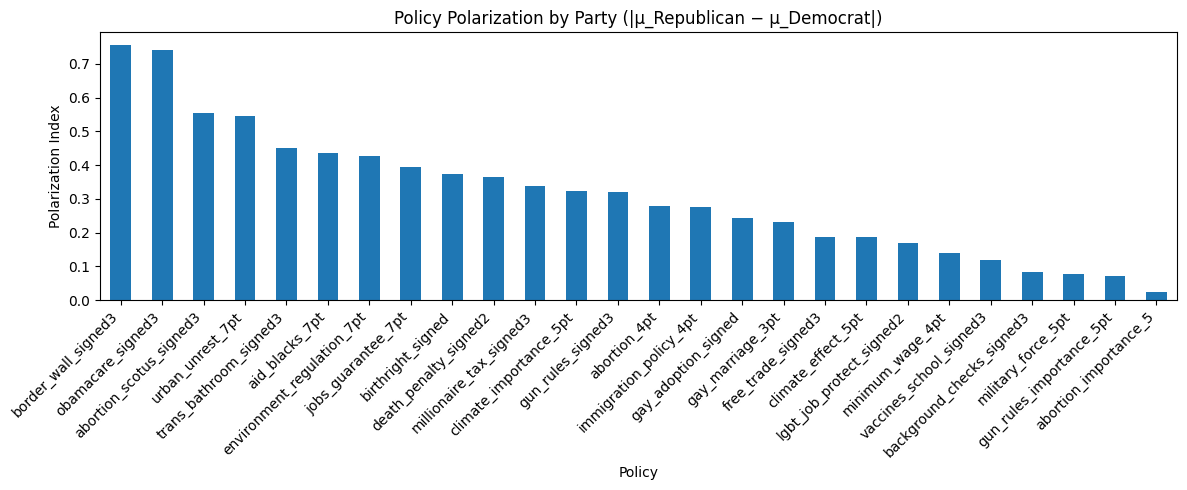


Top 10 Most Polarized Policies:
1. border_wall_signed3: 0.7560
2. obamacare_signed3: 0.7417
3. abortion_scotus_signed3: 0.5540
4. urban_unrest_7pt: 0.5472
5. trans_bathroom_signed3: 0.4518
6. aid_blacks_7pt: 0.4351
7. environment_regulation_7pt: 0.4279
8. jobs_guarantee_7pt: 0.3950
9. birthright_signed: 0.3749
10. death_penalty_signed2: 0.3633


In [34]:
# Calculate polarization by party for each policy
polarization = {}

for col in policy_cols:
    # Get data for each party
    dem_data = clean_normalized[col][clean['party_id_signed'] == -1]
    rep_data = clean_normalized[col][clean['party_id_signed'] == 1]
    
    # Calculate polarization as absolute difference of means
    polarization[col] = abs(rep_data.mean() - dem_data.mean())

# Sort polarization for plotting
polarization_sorted = dict(sorted(polarization.items(), key=lambda x: x[1], reverse=True))

# Plot 2: Polarization
plt.figure(figsize=(12, 5))
pd.Series(polarization_sorted).plot(kind='bar')
plt.title('Policy Polarization by Party (|μ_Republican − μ_Democrat|)')
plt.ylabel('Polarization Index')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Polarized Policies:")
for i, (policy, value) in enumerate(list(polarization_sorted.items())[:10], 1):
    print(f"{i}. {policy}: {value:.4f}")

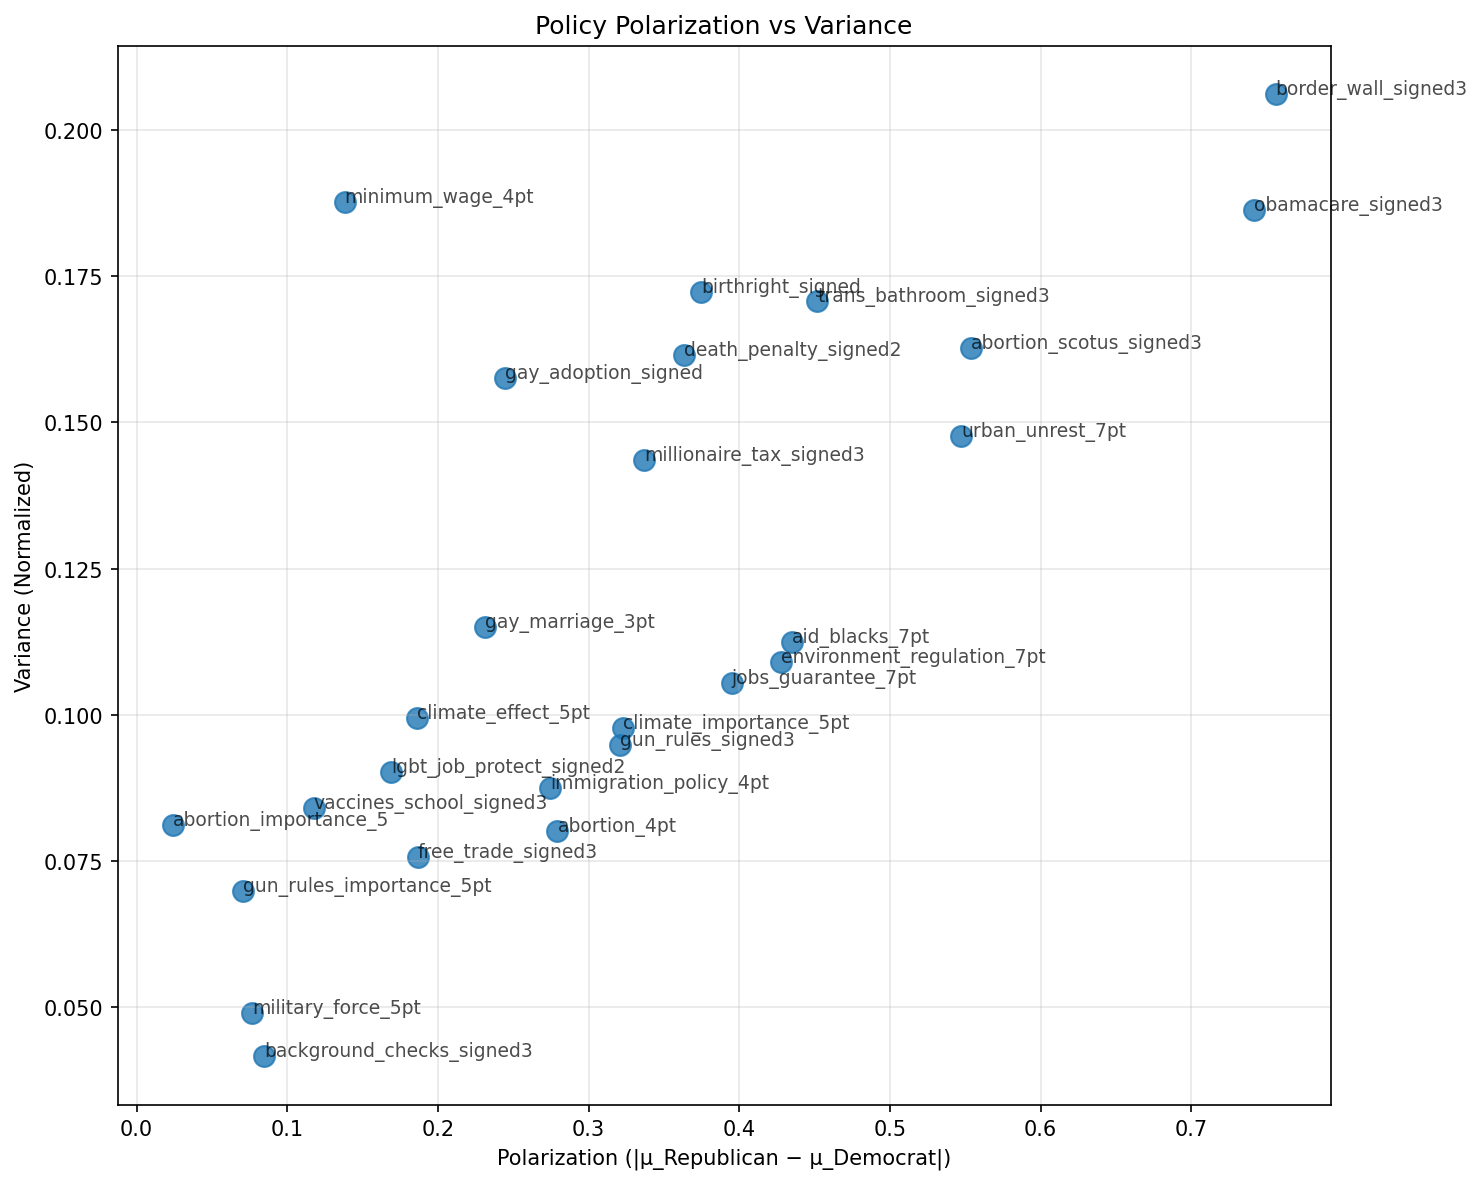

In [39]:
# Plot 3: Polarization vs Variance Scatter Plot
plt.figure(figsize=(10, 8), dpi=150)

# Extract x and y values from dictionaries
x_values = [polarization[policy] for policy in policy_cols]
y_values = [variance[policy] for policy in policy_cols]

plt.scatter(x_values, y_values, s=100, alpha=0.8)

# Add policy labels to points
for policy in policy_cols:
    plt.annotate(policy, (polarization[policy], variance[policy]), 
                fontsize=9, alpha=0.7)

plt.xlabel('Polarization (|μ_Republican − μ_Democrat|)')
plt.ylabel('Variance (Normalized)')
plt.title('Policy Polarization vs Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()